# Looking at cool things with this


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from oxford import parse_imu_csv, parse_vicon_csv

import sys
# from pprint import pprint
sys.path.append("../../..")
from estimation.filtering.ekf import State, EkfParams, EKF
from utils.quaternion import unit, quat_apply, quat_mult
# from PIL import Image
# from dataclasses import dataclass

In [32]:

base = "Oxford Inertial Odometry Dataset/slow walking/data1/syn"
# base = "Oxford Inertial Odometry Dataset/handbag/data1/raw"
imu = parse_imu_csv(f"{base}/imu1.csv")
vicon = parse_vicon_csv(f"{base}/vi1.csv")

print("IMU samples:", len(imu.t))
print("Vicon samples:", len(vicon.t))

IMU samples: 61167
Vicon samples: 61167


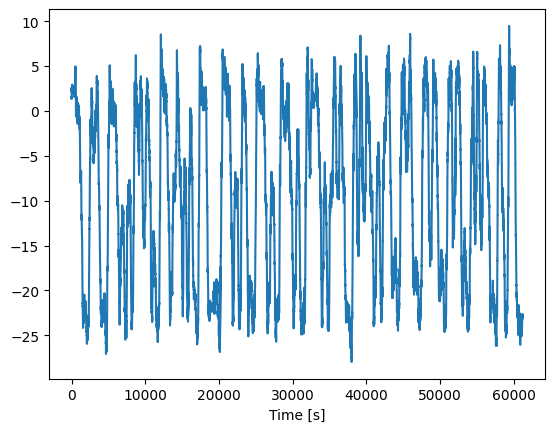

In [33]:
plt.plot(imu.mag[:,1])

# plt.xlim(0,100)
plt.xlabel("Time [s]")
plt.show()

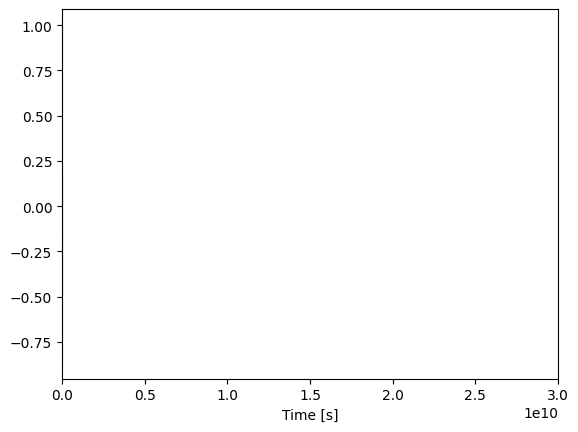

In [34]:
# plt.plot(vicon.position[:,1], vicon.position[:,2])
plt.plot(vicon.t - vicon.t[0], vicon.quaternion[:,0])
plt.plot(vicon.t - vicon.t[0], vicon.quaternion[:,1])
plt.plot(vicon.t - vicon.t[0], vicon.quaternion[:,2])
plt.plot(vicon.t - vicon.t[0], vicon.quaternion[:,3])
plt.xlim(0, 3e10)
plt.xlabel("Time [s]")
plt.show()

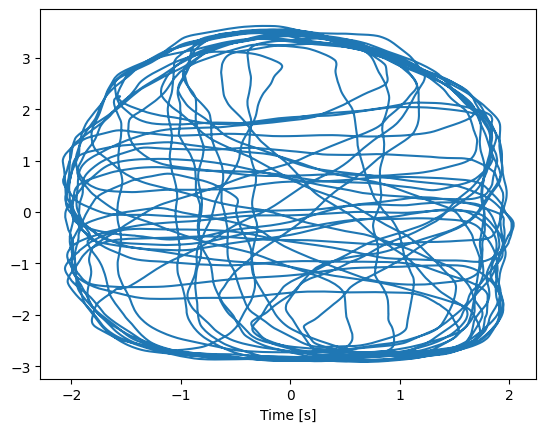

In [35]:
plt.plot(vicon.position[:,0], vicon.position[:,1])
# plt.plot(vicon.position[:100,0], vicon.position[:100,2])
# plt.plot(vicon.t - vicon.t[0], vicon.position[:,0])
# plt.plot(vicon.t - vicon.t[0], vicon.quaternion[:,1])
# plt.plot(vicon.t - vicon.t[0], vicon.quaternion[:,2])
# plt.plot(vicon.t - vicon.t[0], vicon.quaternion[:,3])

# plt.xlim(0, 3e10)
plt.xlabel("Time [s]")
plt.show()

# EKF time babyyyy
Walking one

In [46]:
base = "Oxford Inertial Odometry Dataset/slow walking/data1/syn"
imu = parse_imu_csv(f"{base}/imu1.csv")
vicon = parse_vicon_csv(f"{base}/vi1.csv")

pos0 = vicon.position[0]
quat0 = vicon.quaternion[0]

print(f"Initial position [m]: {pos0}")
print(f"Initial quat: {quat0}")

Initial position [m]: [-1.557   2.247   1.2229]
Initial quat: [ 0.98465   -0.17449   -0.0017112 -0.003099 ]


## Noise characterization

sigma_accel [m/s2]: [0.07412363 0.06006345 0.08454008]


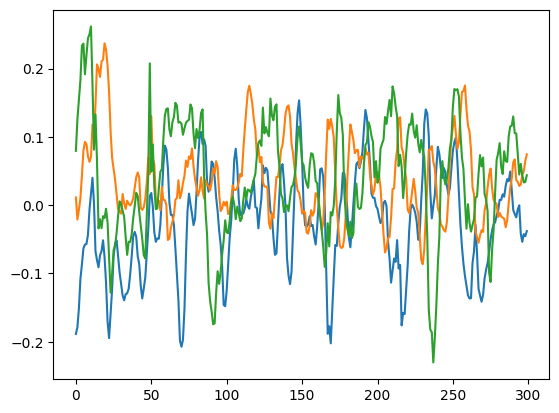

In [52]:
# Accel
start, stop = (0, 300)
t = (imu.t - imu.t[0])[start:stop]
stationary = imu.accel[start:stop]

std_accel = np.array([
    np.std(stationary[:,0]),
    np.std(stationary[:,1]),
    np.std(stationary[:,2])
], dtype=float)

print(f"sigma_accel [m/s2]: {std_accel}")

plt.plot(stationary)
plt.show()

sigma_accel [rad/s]: [0.04031036 0.03989623 0.02870878]


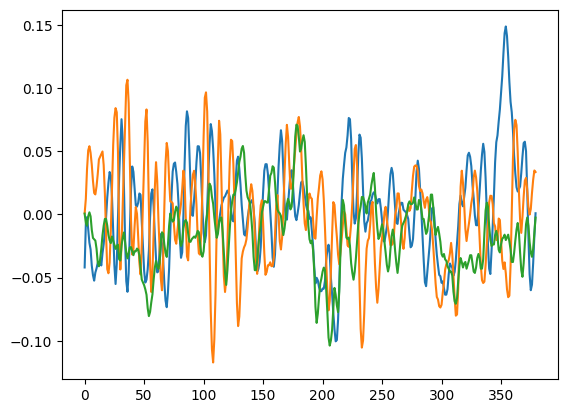

In [57]:
# Gyro
start, stop = (20, 400)
t = (imu.t - imu.t[0])[start:stop]
stationary = imu.gyro[start:stop]

std_gyro = np.array([
    np.std(stationary[:,0]),
    np.std(stationary[:,1]),
    np.std(stationary[:,2])
], dtype=float)

print(f"sigma_accel [rad/s]: {std_gyro}")

plt.plot(stationary)
plt.show()

In [39]:
# # Q (Just bc)
# start, stop = (1000, 8000)
# t = (vicon.t - vicon.t[0])[start:stop]
# stationary = vicon.position[start:stop]

# sigma_px = np.std(stationary[:,0])
# sigma_py = np.std(stationary[:,1])
# sigma_pz = np.std(stationary[:,2])

# print(f"Position sigmas [m]: {sigma_px}, {sigma_py}, {sigma_pz}")

# plt.plot(t,stationary)
# plt.show()

# # Q (Just bc)
# start, stop = (500, 4000)
# t = (vicon.t - vicon.t[0])[start:stop]
# stationary = vicon.quaternion[start:stop]

# sigma_qw = np.std(stationary[:,0])
# sigma_qx = np.std(stationary[:,1])
# sigma_qy = np.std(stationary[:,2])
# sigma_qz = np.std(stationary[:,3])

# print(f"Position sigmas [m]: {sigma_qw}, {sigma_qx}, {sigma_qy}, {sigma_qz}")

# plt.plot(t,stationary)
# plt.show()

In [59]:
def state_model(mu, dt, a_body, w_body):
        p = mu[0:3]
        v = mu[3:6]
        q = unit(mu[6:10])

        a_global = quat_apply(q, a_body)

        # w_global = quat_apply(q, w_body) # I think this doesnt matter

        mu_next = np.zeros(10)
        mu_next[0:3] = p + (v * dt) + (0.5 * a_body * dt * dt)
        mu_next[3:6] = v + (a_global * dt)
        mu_next[6:10] = q + 0.5 * quat_mult(q, [0, *w_body]) * dt
        return mu_next

def state_jacob(mu, dt, a_body, w_body):

        q = mu[6:10]
        w = w_body
        dt = dt

        F_dot = np.eye(10)

        F_dot[0:3, 3:6] = np.eye(3)

        # Quaternion row
        F_dot[6:10, 6:10] += 0.5 * np.array([
            [0, -w[0], -w[1], -w[2]],
            [w[0], 0, w[2], -w[1]],
            [w[1], -w[2], 0, w[0]],
            [w[2], w[1], -w[0], 0]
        ])


        Q_F = np.array([
            [q[1], q[0], -q[3], q[2]],
            [q[2], q[3], q[0], -q[1]],
            [q[3], -q[2], q[1], q[0]],
        ])

        term2 = np.zeros((4,4))
        term2[0, 1:4] = a_body
        term2[1:4, 0] = a_body


        term2[1:4, 1:4] = np.array([
            [0, -a_body[2], a_body[1]],
            [a_body[2], 0, -a_body[0]],
            [-a_body[1], a_body[0], 0]
        ])

        F_dot[3:6, 6:10] = 2 * Q_F @ term2

        # e_val, e_vec = np.linalg.eig(self.F_dot)
        # print(e_val)
        # breakpoint()
        # Angular velocity propogated by measurement

        F_dot = F_dot * dt
        
        return F_dot

In [41]:
# class EKF:
#     def __init__(self, mu0: np.ndarray, Sigma0: np.ndarray, dt: float):
#         assert np.shape(mu0) == (10,)
#         assert np.shape(Sigma0) == (10,10)

#         self.Sigma = Sigma0
#         self.mu = mu0

#         self.dt = dt

#         # self.R: np.ndarray = np.eye(3) * 0.01**2  # Measurement noise covariance (uncertainty in measurements)
#         self.R = np.diag(std_accel)

#         # Process noise
#         self.Q = np.diag([ 
#             0.1, 0.1, 0.1, # p
#             0.1, 0.1, 0.1, # v
#             1e-6, 1e-6, 1e-6, 1e-6 # q
#         ])


#     def calc_F_jacobian(self, accel: np.ndarray, w_body: np.ndarray):

#         q = self.mu[6:10]
#         w = w_body
#         dt = self.dt

#         self.F_dot = np.eye(10)

#         self.F_dot[0:3, 3:6] = np.eye(3)

#         # Quaternion row
#         self.F_dot[6:10, 6:10] += 0.5 * np.array([
#             [0, -w[0], -w[1], -w[2]],
#             [w[0], 0, w[2], -w[1]],
#             [w[1], -w[2], 0, w[0]],
#             [w[2], w[1], -w[0], 0]
#         ])


#         Q_F = np.array([
#             [q[1], q[0], -q[3], q[2]],
#             [q[2], q[3], q[0], -q[1]],
#             [q[3], -q[2], q[1], q[0]],
#         ])

#         term2 = np.zeros((4,4))
#         term2[0, 1:4] = accel
#         term2[1:4, 0] = accel


#         term2[1:4, 1:4] = np.array([
#             [0, -accel[2], accel[1]],
#             [accel[2], 0, -accel[0]],
#             [-accel[1], accel[0], 0]
#         ])

#         self.F_dot[3:6, 6:10] = 2 * Q_F @ term2

#         # e_val, e_vec = np.linalg.eig(self.F_dot)
#         # print(e_val)
#         # breakpoint()
#         # Angular velocity propogated by measurement

#         self.F_dot = self.F_dot * dt
        
#         return self.F_dot
    

#     def predict(self, a_meas_b: np.ndarray, w_meas_body: np.ndarray):
#         """TODO: Add jacobian of H matrix"""
#         p = self.mu[0:3]
#         v = self.mu[3:6]
#         q = unit(self.mu[6:10])

#         self.a_global = quat_apply(q, a_meas_b)
#         self.a_global[2] -= 9.81

#         self.w_global = quat_apply(q, w_meas_body)


#         #### State Transition ####
#         self.mu[0:3] = p + (v * self.dt) + (0.5 * self.a_global * self.dt * self.dt)
#         self.mu[3:6] = v + (self.a_global * self.dt)
#         q_new = q + 0.5 * quat_mult(q, [0, *self.w_global]) * self.dt
#         self.mu[6:10] = unit(q_new)

#         # print(self.state)
#         # return


#         # Propagating P
#         self.calc_F_jacobian(self.a_global, w_meas_body)
#         # print(self.P[:3,:3])
#         # try:
#         self.P = self.F_dot @ self.Sigma @ self.F_dot.T + self.Q
#         # except RuntimeWarning:
#         #     breakpoint()


#     # mu_predict = sat_state_model(SAT_mu[i], u_arr[i], dt, J)
#     # Sigma_predict = A @ SAT_Sigma[i] @ A.T + Q

#     # K = Sigma_predict @ C.T @ inv(C @ Sigma_predict @ C.T + R)

#     # resid = meas_arr[i] - sat_measurement_model(SAT_mu[i], max_c)
#     # SAT_mu[i+1] = mu_predict + K @ resid
#     # SAT_Sigma[i+1] = Sigma_predict - K @ C @ Sigma_predict

#     def update(self, p_glob: np.ndarray):

#         self.H = np.zeros((3, 10))
#         self.H[0:3, 0:3] = np.eye(3)

#         # Innovation
#         self.S = self.H @ self.Sigma @ self.H.T + self.R

#         # Kalman gain
#         self.K = self.Sigma @ self.H.T @ np.linalg.inv(self.S)

#         # Update State
#         self.mu = self.mu + self.K @ (p_glob - self.mu[0:3])
#         self.mu[6:10] = unit(self.mu[6:10])

#         # Update covariance
#         self.Sigma = (np.eye(10) - self.K @ self.H) @ self.Sigma

In [60]:
mu0 = np.array(pos0.tolist() + [0,0,0] + quat0.tolist())
Sigma0 = np.eye(10) * 0.1
print(mu0)
print(Sigma0)

Q = np.eye(10) * 0.1

[-1.5570e+00  2.2470e+00  1.2229e+00  0.0000e+00  0.0000e+00  0.0000e+00
  9.8465e-01 -1.7449e-01 -1.7112e-03 -3.0990e-03]
[[0.1 0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.1 0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.1 0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.1 0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.1 0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.1 0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.1 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.1 0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.1 0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1]]


In [76]:
t = 0
dt = imu.t[1] - imu.t[0]
dt = 0.001

N = len(imu.gyro)

mus = np.zeros((N, 10))
Sigmas = np.zeros((N, 10, 10))

mus[0] = mu0
Sigmas[0] = Sigma0

a_arr = imu.accel
w_arr = imu.gyro

for i in range(N-1):

    A = state_jacob(mus[i], dt, a_arr[i], w_arr[i])

    mu_predict = state_model(mus[i], dt, a_arr[i], w_arr[i])
    Sigma_predict = A @ Sigmas[i] @ A.T + Q

    # K = Sigma_predict @ C.T @ inv(C @ Sigma_predict @ C.T + R)

    # resid = meas_arr[i] - measurement_model(mu[i], max_c)
    mus[i+1] = mu_predict #+ K @ resid
    Sigmas[i+1] = Sigma_predict #- K @ C @ Sigma_predict

    t += dt


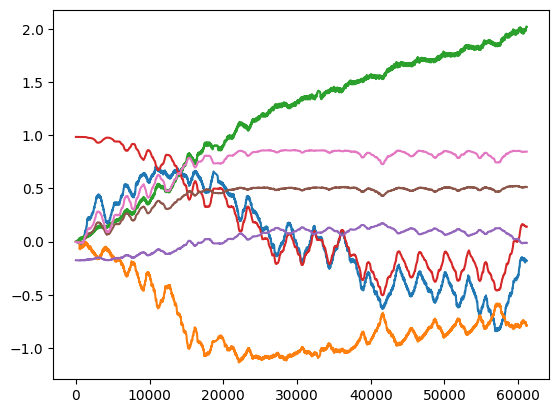

In [87]:
# plt.plot(imu.t - imu.t[0], mus[:,6:10])
plt.plot(mus[:,3:])
# plt.xlim()
plt.show()
# plt.plot(vicon.t - vicon.t[0], vicon.quaternion)
# plt.show()